In [102]:
## Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
from sklearn.model_selection import train_test_split 
from sklearn.impute import KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, ConfusionMatrixDisplay)
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.patches as mpatches

In [103]:
df = pd.read_csv("C:/Users/masel/OneDrive/Desktop/SQL_Learing journey/Project_Berka/Loan Defualt prediction model/Model_training_dataset_Final.csv")

In [104]:
df.head()

,loan_id,Gender,Age_at_loan,Months_open_before_loan,Amount,Duration,Monthly_payments,Default_flag,Total_num_trans,total_balance,avg_balance,Credit_card_issued,No_credict_card,Junior_Credit_card,Classic_Credit_card,Gold_Credit_card,District_account_opened,Distict_Avg_Salary,Unemploymenr_rate_1995,Unemploymenr_rate_1996
0,4959,0,48,10,80952,24,3373,0,54,1759893.7,32590.624074,0,1,0,0,0,1,12541.0,0.29,0.43
1,4961,1,57,12,30276,12,2523,1,80,2015767.4,25197.092500,0,1,0,0,0,21,9104.0,1.51,2.07
2,4962,0,35,16,30276,12,2523,0,164,10330567.4,62991.264634,0,1,0,0,0,68,9893.0,4.09,4.72
3,4967,0,46,13,318480,60,5308,1,116,4634660.6,39953.970690,0,1,0,0,0,20,8547.0,2.65,3.64
4,4968,1,58,8,110736,48,2307,0,55,1726089.7,31383.449091,0,1,0,0,0,19,8402.0,3.13,3.98


In [105]:
df.shape

(682, 20)

In [106]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 682 entries, 0 to 681
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   loan_id                  682 non-null    int64  
 1   Gender                   682 non-null    int64  
 2   Age_at_loan              682 non-null    int64  
 3   Months_open_before_loan  682 non-null    int64  
 4   Amount                   682 non-null    int64  
 5   Duration                 682 non-null    int64  
 6   Monthly_payments         682 non-null    int64  
 7   Default_flag             682 non-null    int64  
 8   Total_num_trans          682 non-null    int64  
 9   total_balance            682 non-null    float64
 10  avg_balance              682 non-null    float64
 11  Credit_card_issued       682 non-null    int64  
 12  No_credict_card          682 non-null    int64  
 13  Junior_Credit_card       682 non-null    int64  
 14  Classic_Credit_card      6

In [107]:
## Check for null values
df.isnull().sum()

loan_id                    0
Gender                     0
Age_at_loan                0
Months_open_before_loan    0
Amount                     0
Duration                   0
Monthly_payments           0
Default_flag               0
Total_num_trans            0
total_balance              0
avg_balance                0
Credit_card_issued         0
No_credict_card            0
Junior_Credit_card         0
Classic_Credit_card        0
Gold_Credit_card           0
District_account_opened    0
Distict_Avg_Salary         8
Unemploymenr_rate_1995     8
Unemploymenr_rate_1996     8
dtype: int64

In [108]:
## Impute columns with nulls with KNN imputer 
cols_with_nulls = ['Distict_Avg_Salary', 'Unemploymenr_rate_1995', 'Unemploymenr_rate_1996']
knn_imputer = KNNImputer(n_neighbors=5)
df[cols_with_nulls] = knn_imputer.fit_transform(df[cols_with_nulls])


In [109]:
## Double check if the nulls are removed
print("\nNull counts after KNN imputation:")
print(df[cols_with_nulls].isnull().sum())


Null counts after KNN imputation:
Distict_Avg_Salary        0
Unemploymenr_rate_1995    0
Unemploymenr_rate_1996    0
dtype: int64


In [110]:
df.describe()

,loan_id,Gender,Age_at_loan,Months_open_before_loan,Amount,Duration,Monthly_payments,Default_flag,Total_num_trans,total_balance,avg_balance,Credit_card_issued,No_credict_card,Junior_Credit_card,Classic_Credit_card,Gold_Credit_card,District_account_opened,Distict_Avg_Salary,Unemploymenr_rate_1995,Unemploymenr_rate_1996
count,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,6.820000e+02,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000,682.000000
mean,6172.466276,0.510264,37.630499,12.601173,151410.175953,36.492669,4190.664223,0.111437,80.196481,3.571490e+06,43606.789462,0.249267,0.750733,0.030792,0.195015,0.023460,37.489736,9484.615727,2.905935,3.510549
std,682.579279,0.500262,12.768289,5.414062,113372.406310,17.075219,2215.830344,0.314903,44.777664,2.498444e+06,13481.855233,0.432906,0.432906,0.172880,0.396503,0.151472,25.184326,1294.142231,1.847285,2.106975
min,4959.000000,0.000000,13.000000,3.000000,4980.000000,12.000000,304.000000,0.000000,2.000000,1.070000e+04,5350.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,8110.000000,0.290000,0.430000
25%,5577.500000,0.000000,27.000000,8.000000,66732.000000,24.000000,2477.000000,0.000000,45.000000,1.705712e+06,32833.034787,0.000000,1.000000,0.000000,0.000000,0.000000,13.000000,8546.000000,1.600000,1.960000
50%,6176.500000,1.000000,37.000000,12.000000,116928.000000,36.000000,3934.000000,0.000000,77.000000,2.974525e+06,43159.249595,0.000000,1.000000,0.000000,0.000000,0.000000,39.000000,8991.000000,2.790000,3.490000
75%,6752.500000,1.000000,48.000000,17.000000,210654.000000,48.000000,5813.500000,0.000000,112.000000,4.826820e+06,53613.958260,0.000000,1.000000,0.000000,0.000000,0.000000,60.000000,9897.000000,3.850000,4.720000
max,7308.000000,1.000000,61.000000,22.000000,590820.000000,60.000000,9910.000000,1.000000,218.000000,1.365259e+07,79500.538095,1.000000,1.000000,1.000000,1.000000,1.000000,77.000000,12541.000000,7.340000,9.400000


In [111]:
## Correlation matrix
corr_matrix = df.corr(numeric_only=True)
default_corr = corr_matrix[['Default_flag']].drop('Default_flag').sort_values(
    by='Default_flag', ascending=False
)

print("Correlation with Default Flag:")
print(default_corr)


Correlation with Default Flag:
                         Default_flag
Monthly_payments             0.182440
Amount                       0.167525
No_credict_card              0.150203
Unemploymenr_rate_1995       0.028300
Unemploymenr_rate_1996       0.028172
Duration                     0.025823
Gender                       0.020693
District_account_opened      0.020512
Age_at_loan                 -0.002892
Gold_Credit_card            -0.024105
Distict_Avg_Salary          -0.026302
Junior_Credit_card          -0.036149
Months_open_before_loan     -0.077249
loan_id                     -0.077255
Total_num_trans             -0.078826
total_balance               -0.121645
Classic_Credit_card         -0.139023
Credit_card_issued          -0.150203
avg_balance                 -0.159760


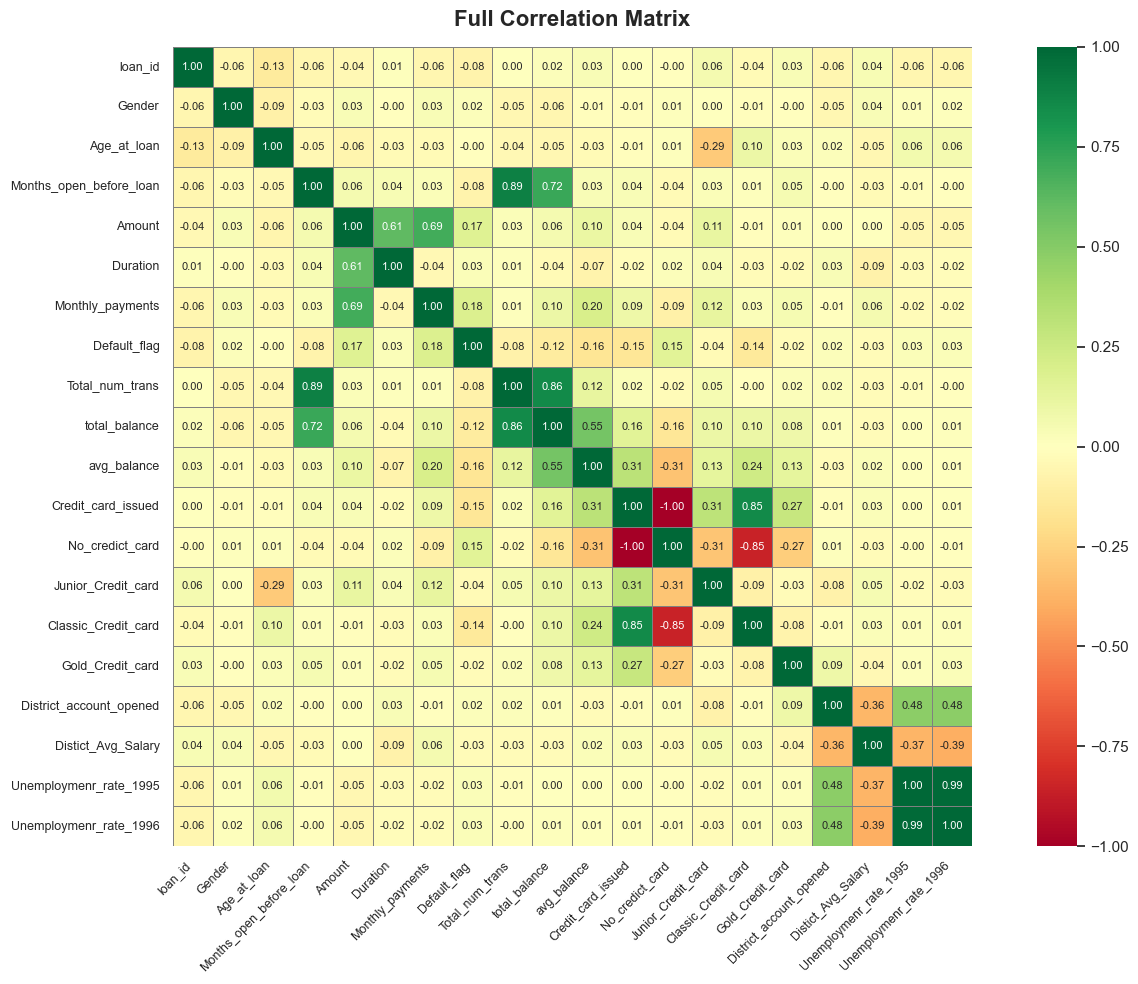

In [112]:
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    linecolor='gray',
    square=True,
    annot_kws={"size": 8}
)
plt.title('Full Correlation Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('full_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [113]:
## Spliting data into x and y variables
x= df.loc[:, ["Gender", "Age_at_loan", "Months_open_before_loan", "Amount", "Duration", "Monthly_payments", "Total_num_trans", "total_balance", "total_balance", "Credit_card_issued", "No_credict_card", "Junior_Credit_card","Classic_Credit_card", "Gold_Credit_card", "District_account_opened", "Distict_Avg_Salary","Unemploymenr_rate_1995","Unemploymenr_rate_1996" ]]
x.head()

,Gender,Age_at_loan,Months_open_before_loan,Amount,Duration,Monthly_payments,Total_num_trans,total_balance,total_balance,Credit_card_issued,No_credict_card,Junior_Credit_card,Classic_Credit_card,Gold_Credit_card,District_account_opened,Distict_Avg_Salary,Unemploymenr_rate_1995,Unemploymenr_rate_1996
0,0,48,10,80952,24,3373,54,1759893.7,1759893.7,0,1,0,0,0,1,12541.0,0.29,0.43
1,1,57,12,30276,12,2523,80,2015767.4,2015767.4,0,1,0,0,0,21,9104.0,1.51,2.07
2,0,35,16,30276,12,2523,164,10330567.4,10330567.4,0,1,0,0,0,68,9893.0,4.09,4.72
3,0,46,13,318480,60,5308,116,4634660.6,4634660.6,0,1,0,0,0,20,8547.0,2.65,3.64
4,1,58,8,110736,48,2307,55,1726089.7,1726089.7,0,1,0,0,0,19,8402.0,3.13,3.98


In [114]:
y = df.loc[:,["Default_flag"]]
y.head()

,Default_flag
0,0
1,1
2,0
3,1
4,0


In [115]:
##Split training and test data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [116]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test) 

In [117]:
## Fitting Logistical regression model
model = LogisticRegression()
model.fit(x_train, y_train)

C:\Users\masel\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\masel\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [119]:
print("=" * 55)
print("          LOGISTIC REGRESSION — MODEL EVALUATION")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

          LOGISTIC REGRESSION — MODEL EVALUATION

  Accuracy  : 0.8732
  ROC-AUC   : 0.6007

Classification Report:
              precision    recall  f1-score   support

  No Default       0.87      1.00      0.93       179
     Default       0.00      0.00      0.00        26

    accuracy                           0.87       205
   macro avg       0.44      0.50      0.47       205
weighted avg       0.76      0.87      0.81       205



C:\Users\masel\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\masel\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\masel\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [120]:
## Decision Tree

In [121]:
## Fit Descison tree
dt_model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced',  
    max_depth=10               
)
dt_model.fit(x_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [122]:
y_pred       = dt_model.predict(x_test)
y_pred_proba = dt_model.predict_proba(x_test)[:, 1]

In [123]:
print("=" * 55)
print("           DECISION TREE — MODEL EVALUATION")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

           DECISION TREE — MODEL EVALUATION

  Accuracy  : 0.8195
  ROC-AUC   : 0.6007

Classification Report:
              precision    recall  f1-score   support

  No Default       0.90      0.89      0.90       179
     Default       0.30      0.31      0.30        26

    accuracy                           0.82       205
   macro avg       0.60      0.60      0.60       205
weighted avg       0.82      0.82      0.82       205



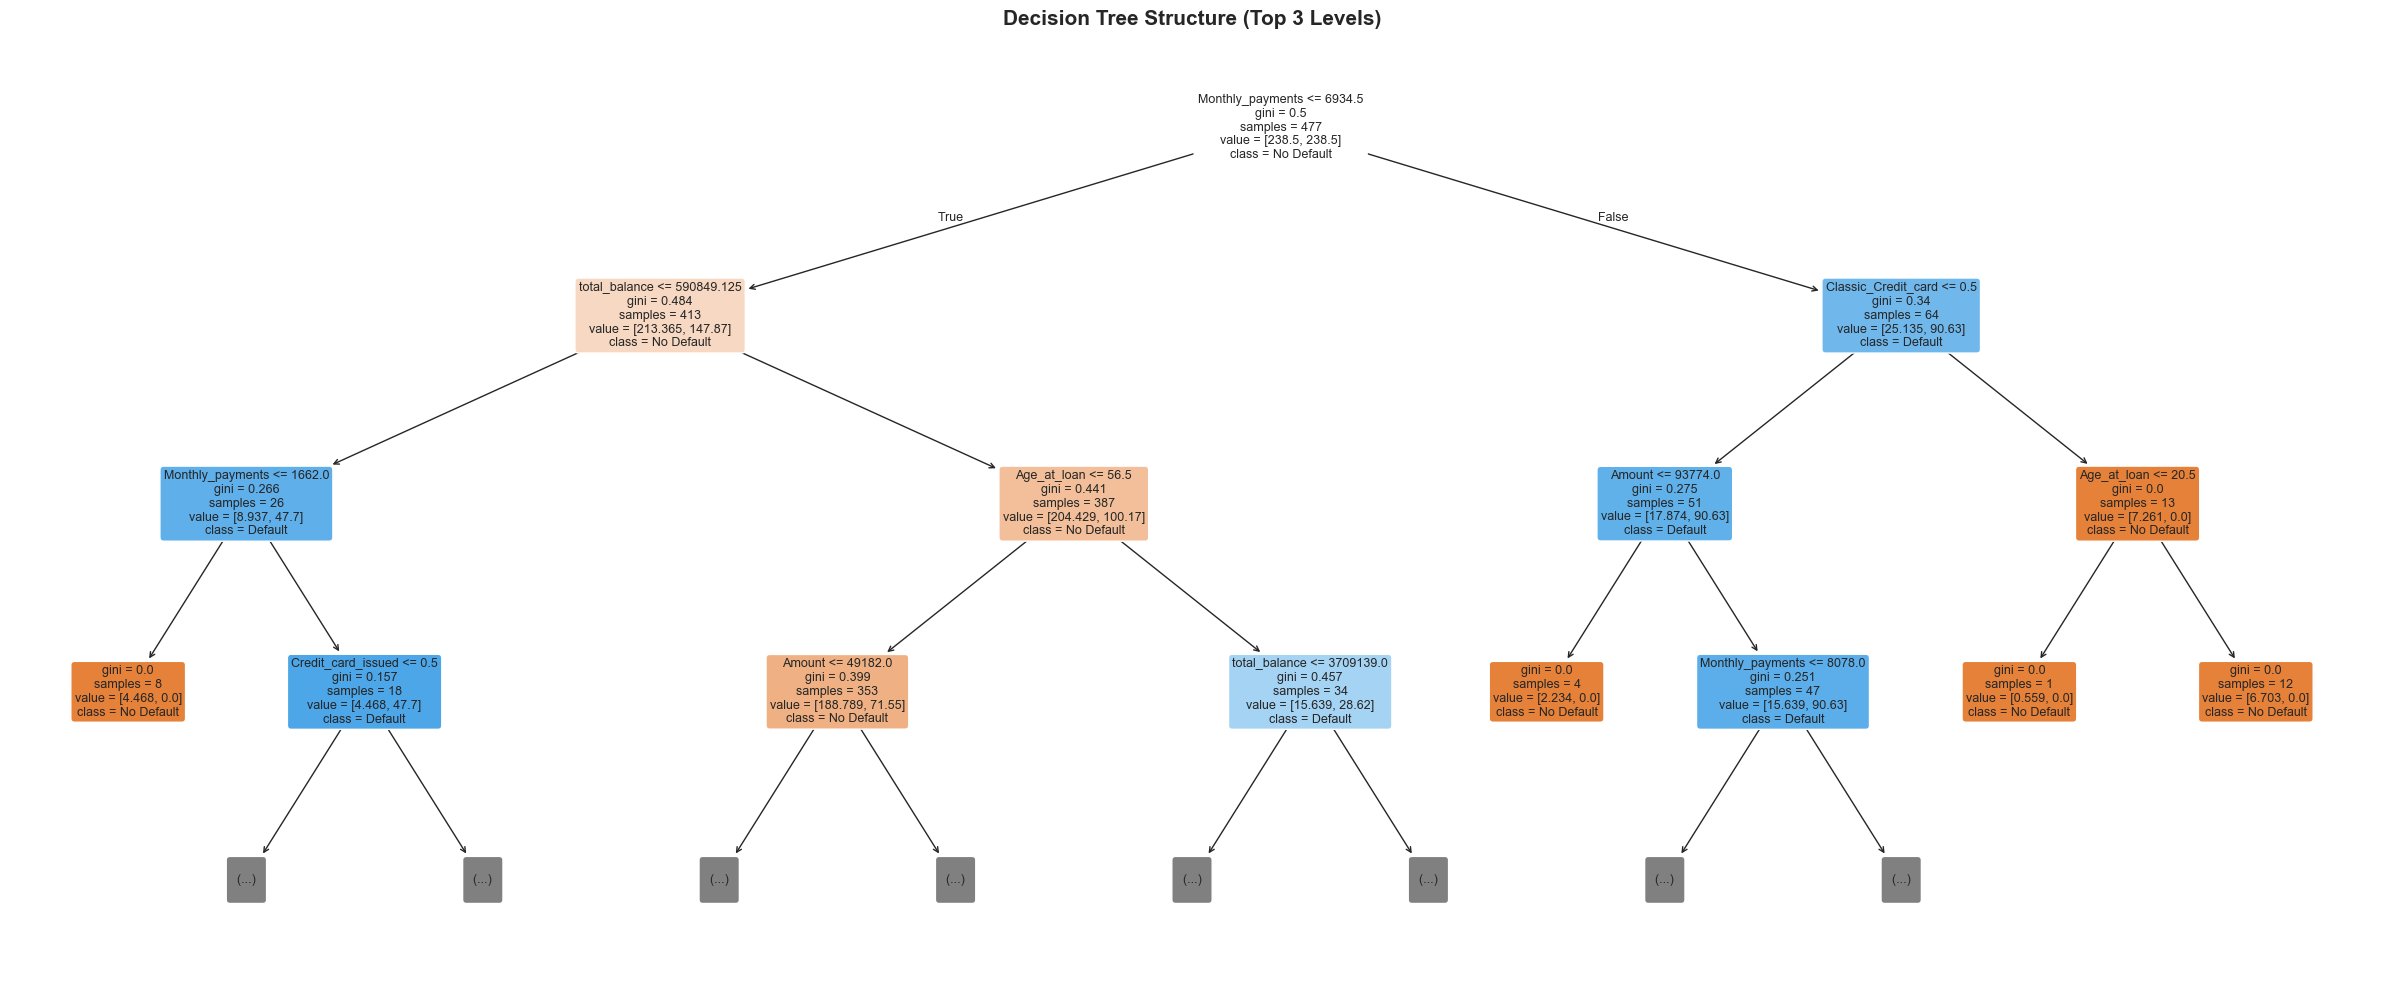

In [124]:
plt.figure(figsize=(24, 10))
plot_tree(
    dt_model,
    feature_names=x_train.columns.tolist(),
    class_names=['No Default', 'Default'],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3             # show top 3 levels for readability
)
plt.title('Decision Tree Structure (Top 3 Levels)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('decision_tree_structure.png', dpi=150, bbox_inches='tight')
plt.show()

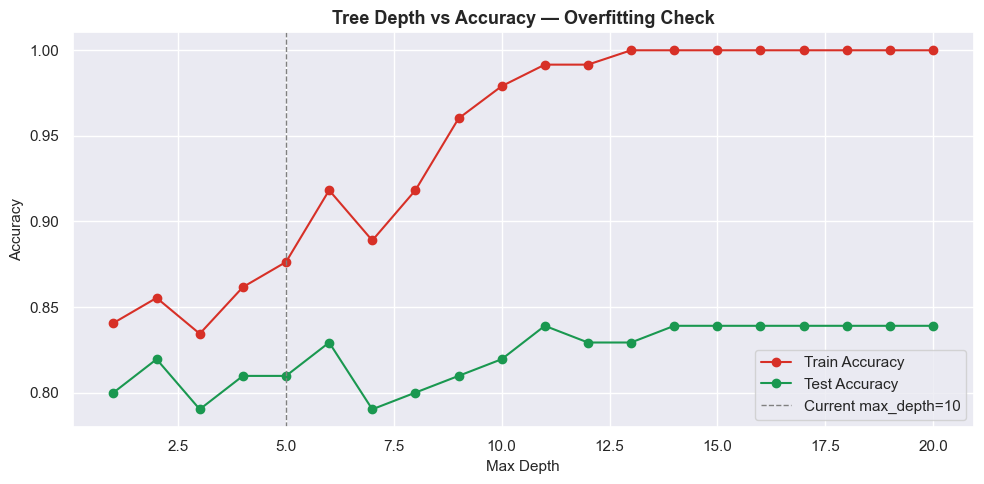

In [125]:
train_scores, test_scores = [], []
depths = range(1, 21)

for depth in depths:
    dt_temp = DecisionTreeClassifier(
        max_depth=depth, random_state=42, class_weight='balanced'
    )
    dt_temp.fit(x_train, y_train)
    train_scores.append(accuracy_score(y_train, dt_temp.predict(x_train)))
    test_scores.append(accuracy_score(y_test,  dt_temp.predict(x_test)))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores, 'o-', color='#d73027', label='Train Accuracy')
plt.plot(depths, test_scores,  'o-', color='#1a9850', label='Test Accuracy')
plt.axvline(x=5, color='gray', linestyle='--', linewidth=1, label='Current max_depth=10')
plt.xlabel('Max Depth', fontsize=11)
plt.ylabel('Accuracy', fontsize=11)
plt.title('Tree Depth vs Accuracy — Overfitting Check', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('decision_tree_depth_vs_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

In [126]:
## Random Forest

In [127]:
rf_model = RandomForestClassifier(
    n_estimators=150,         
    max_depth=5,              
    random_state=42,
    class_weight='balanced',  
    n_jobs=-1                 
)
rf_model.fit(x_train, y_train)

C:\Users\masel\anaconda3\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,150
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [128]:
y_pred       = rf_model.predict(x_test)
y_pred_proba = rf_model.predict_proba(x_test)[:, 1]

In [129]:
print("=" * 55)
print("           RANDOM FOREST — MODEL EVALUATION")
print("=" * 55)
print(f"\n  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_pred_proba):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

           RANDOM FOREST — MODEL EVALUATION

  Accuracy  : 0.8780
  ROC-AUC   : 0.7697

Classification Report:
              precision    recall  f1-score   support

  No Default       0.90      0.97      0.93       179
     Default       0.54      0.27      0.36        26

    accuracy                           0.88       205
   macro avg       0.72      0.62      0.65       205
weighted avg       0.86      0.88      0.86       205



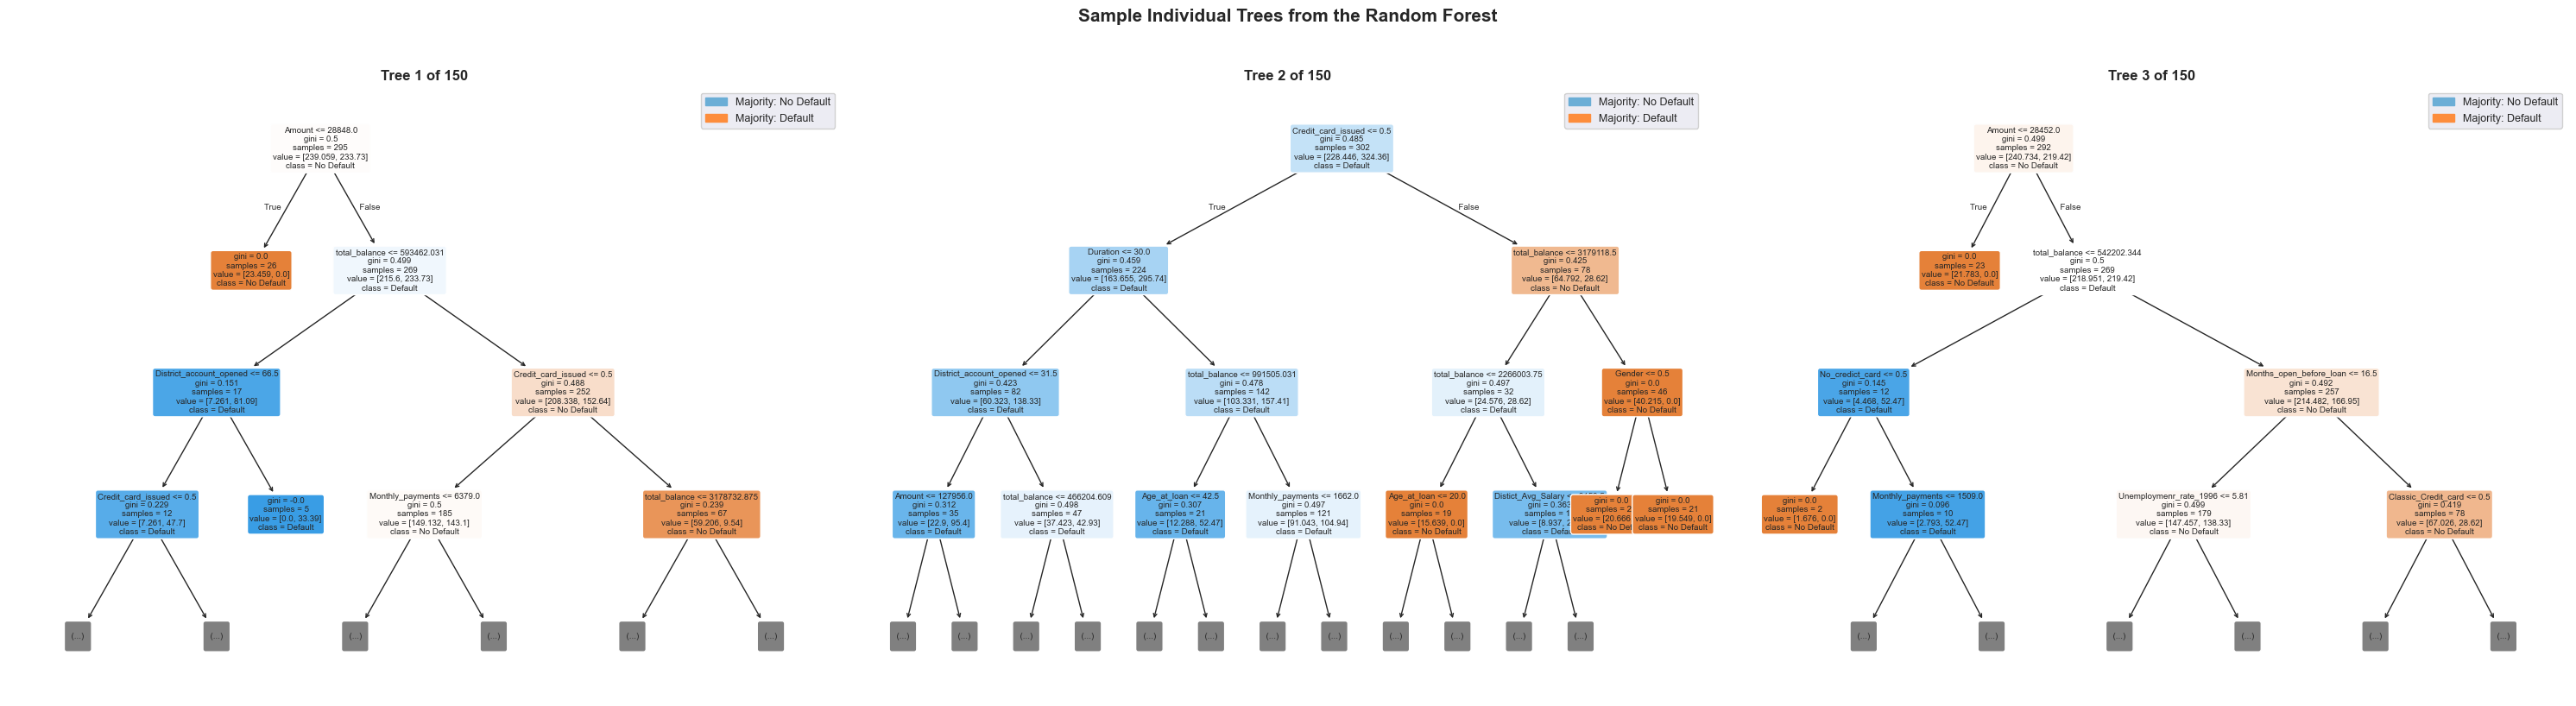

In [130]:
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

no_default_patch = mpatches.Patch(color='#6baed6', label='Majority: No Default')
default_patch    = mpatches.Patch(color='#fd8d3c', label='Majority: Default')

for i, ax in enumerate(axes):
    plot_tree(
        rf_model.estimators_[i],            # plot 1st, 2nd and 3rd tree
        feature_names=x_train.columns.tolist(),
        class_names=['No Default', 'Default'],
        filled=True,
        rounded=True,
        fontsize=7,
        max_depth=3,
        ax=ax
    )
    ax.set_title(f'Tree {i + 1} of {rf_model.n_estimators}',
                 fontsize=12, fontweight='bold')
    ax.legend(handles=[no_default_patch, default_patch],
              loc='upper right', fontsize=9, framealpha=0.9)

plt.suptitle('Sample Individual Trees from the Random Forest',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('random_forest_sample_trees.png', dpi=150, bbox_inches='tight')
plt.show()